# QF 627 Programming and Computational Finance
## Problem Set `4` | `Questions`

> "Hi Team! 👋

> The current notebook contains 8 questions that help you review our course content.

> Each question asks you to answer with specific results. Some questions are the `reverse-engineering-type` questions as I have asked in exercise problem set 3. Other questions require direct answers (because, given the nature of the question, reverse-engineering is not feasible).

> These questions won’t be difficult to solve—and working through them will strengthen your understanding of the learning materials. This week’s questions ask you to preview the lecture note script for Lesson 4, which we will continue in Lesson 5, and then attempt to answer the exercises.

> This preview exercise will help you consolidate the upcoming lessons more effectively. Once you have completed it, please submit your script via eLearn.

> Enjoy!"

##### First, let's do some quick exercise with stock prices data.

### <font color = green> Activation of necessary libraries. </font>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

In [ ]:
def compute_drawdown(cumulative_returns):
    max_gross_performance = cumulative_returns.cummax()
    return max_gross_performance - cumulative_returns

# compute_sharpe_ratio(ibm['strategy_returns'])

In [3]:
def compute_max_drawdown(cumualtive_returns):
    return compute_drawdown(cumualtive_returns).max()

In [4]:
def compute_longest_drawdown_period(cumulative_returns):
    drawdown = compute_drawdown(cumulative_returns)
    periods =\
    (
        np
        .diff(np.append(drawdown[drawdown == 0].index,
                        drawdown.index[-1: ]
                       )
             )
    )
    return periods.max() / np.timedelta64(1, "D")

In [ ]:
def compute_sharpe_ratio(daily_returns):
    """
    get_sharpe_ratio() | Calculate the annualized Sharpe ratio from a series of daily returns.
    Annualized Sharpe ratio computed as:
                sqrt(252) * mean(daily_returns) / std(daily_returns)
    - Assumes 252 trading days per year for annualization. Adjust the
      multiplier for a different convention.
    - Input should be returns (not prices). Convert prices to returns before
      calling this function.
    Parameters:
        daily_returns : array-like (pd.Series or np.ndarray)
    Returns:
        float
    Usage:
        compute_sharpe_ratio(df['strategy_returns'])
    """
    return np.sqrt(252) * daily_returns.mean() / daily_returns.std()

# compute_sharpe_ratio(ibm['strategy_returns'])

In [ ]:
def compute_CAGR(cumulative_returns):
    """
    get_cagr() | Compute Compound Annual Growth Rate (CAGR) from a series of cumulative returns.
        - The function drops missing values and uses the first and last available
      observations to compute CAGR as:
          (last_value / first_value) ** (365.0 / n_days) - 1
      where n_days is the integer number of days between the first and last index.
        - Uses 365-day convention for annualization. For trading-day conventions
        adjust the exponent accordingly.
        - If the series contains a single observation or zero-day span, the result
        may be ill-defined (division by zero or power of inf). Consider checking
        the index span before calling.
    Parameters:
        cumulative_returns : pandas.Series. Time-indexed series of cumulative returns (e.g. cumulative growth factors)
    Returns:
        float
    Usage:
        compute_CAGR(df['cum_strategy_returns'])
    """

    cumulative_returns = cumulative_returns.dropna()
    n_of_days = (cumulative_returns.index[-1] - cumulative_returns.index[0]
                ).days
    cagr =\
    (
        (        
        cumulative_returns.iloc[-1] 
        /
        cumulative_returns.iloc[0]
        ) ** (365.0 / n_of_days)
        - 1
    )
    return cagr

> Let's set some print option.

In [7]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

### <font color = red> Question 1</font>. Please import historical stock data from the web on the following financial instruments, and create the following DataFrame that contains adjusted closing prices. 

### Here, the timeframe should be set between the 13th of October 2014 through the 13th of September 2022 (nine years of data).

- `WMT` Stock of Walmart
- `IBM` Stock of IBM

In [8]:
tickers = ["IBM", "WMT"]

df =\
(
    yf.download(
        tickers,
        start = "2014-10-13",
        end = "2022-09-14",   # need to remember end data is exclusive
    )
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_44493/2478683844.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yf.download(
[*********************100%***********************]  2 of 2 completed


In [9]:
ibm =\
(
    df['Close'][['IBM']]
)

In [10]:
ibm

Ticker,IBM
Date,
2014-10-13,110.969666
2014-10-14,111.138962
2014-10-15,109.899406
2014-10-16,108.744507
2014-10-17,110.080795
...,...
2022-09-07,113.740082
2022-09-08,114.416931
2022-09-09,115.058174


### <font color = red> Question 2</font>. Please run a simple moving average crossover strategy for `IBM`.

### The two moving windows are 20 and 60 days.

### Please show your positions with a plot.

### <mark> What is shown below is a sample to illustrate the type of visualization you should display; the results you obtain may not necessarily be the same.</mark>

In [11]:
def get_sma(df, sma_list):
    """
    Take DF and given list of SMA to enrich df when stock price is in first column
    """
    for window in sma_list:
        df[f"sma_{window}"] =\
        (
            df[df.columns[0]]
            .rolling(window = window)
            .mean()
        )

    return df

1. get sma
2. calculate position and trade
3. plot

In [12]:
# ibm['position'] =\
(
    np.where(
        ibm['IBM'])
)

(array([   0,    1,    2, ..., 1991, 1992, 1993], shape=(1994,)),)

In [13]:
def get_sma(df, sma_list):
    """
    Take DF and given list of SMA to enrich df when stock price is in first column
    """
    for window in sma_list:
        df[f"sma_{window}"] =\
        (
            df[df.columns[0]]
            .rolling(window = window)
            .mean()
        )

    return df

def get_momentum_strategy(df, sma_tuple):
    """
    Apply single stock momentum strategy pipeline to price DataFrame `df`. 
    Price is in first column.
    Adds columns:
      positions, trade, passive_returns, strategy_returns,
      cum_returns, cum_strategy_returns
    Parameters:
      df        : pd.DataFrame with price columns for ticker name as the header
      sma_tuple : tuple of (short_window, long_window) for SMAs
    Returns:
      pd.DataFrame with the above columns
    """
    sma_short, sma_long = sma_tuple
    if sma_short >= sma_long:
        raise ValueError("sma_short must be less than sma_long")
    df = get_sma(df, list(sma_tuple)).dropna()

    df['positions'] =\
    (
        np.where((df[f'sma_{sma_short}'] > df[f'sma_{sma_long}']), 1, -1)
    )
    df['trade'] = \
    (
        df['positions'].diff().fillna(0)
    )
    if df.at[df.index[0], 'positions'] != 0:
        df.at[df.index[0], 'trade'] = df.at[df.index[0], 'positions']
    df['passive_returns'] =\
    (
        np.log(df[df.columns[0]] 
            / df[df.columns[0]].shift(1))
    ).fillna(0)
    df['strategy_returns'] =\
    (
        df['passive_returns'] * df['positions'].shift(1).fillna(0)
    )
    df['cum_returns'] =\
    (
        df['passive_returns'].cumsum().apply(np.exp).fillna(1)
    )
    df['cum_strategy_returns'] =\
    (
        df['strategy_returns'].cumsum().apply(np.exp).fillna(1)
    )

    return df

# sma_tup = (42, 252)
# get_momentum_strategy(df[['GS']], sma_tup)

In [14]:
ibm =\
get_momentum_strategy(ibm, (20, 60));

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_44493/2194077980.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['positions'] =\
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_44493/2194077980.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['trade'] = \
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_44493/2194077980.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = va

In [15]:
ibm

Ticker,IBM,sma_20,sma_60,positions,trade,passive_returns,strategy_returns,cum_returns,cum_strategy_returns
Date,,,,,,,,,
2015-01-07,94.396294,96.620591,99.068447,-1,-1.0,0.000000,0.000000,1.000000,1.000000
2015-01-08,96.447990,96.481478,98.826419,-1,0.0,0.021502,-0.021502,1.021735,0.978727
2015-01-09,96.868080,96.438861,98.588571,-1,0.0,0.004346,-0.004346,1.026185,0.974483
2015-01-12,95.242554,96.297922,98.344290,-1,0.0,-0.016923,0.016923,1.008965,0.991115
2015-01-13,95.467766,96.341451,98.123011,-1,0.0,0.002362,-0.002362,1.011351,0.988777
...,...,...,...,...,...,...,...,...,...
2022-09-07,113.740082,118.133904,118.805320,-1,0.0,0.007782,-0.007782,1.204921,0.376970
2022-09-08,114.416931,117.998977,118.731712,-1,0.0,0.005933,-0.005933,1.212091,0.374740
2022-09-09,115.058174,117.849799,118.659851,-1,0.0,0.005589,-0.005589,1.218884,0.372652


In [16]:
ibm.columns

Index(['IBM', 'sma_20', 'sma_60', 'positions', 'trade', 'passive_returns',
       'strategy_returns', 'cum_returns', 'cum_strategy_returns'],
      dtype='object', name='Ticker')

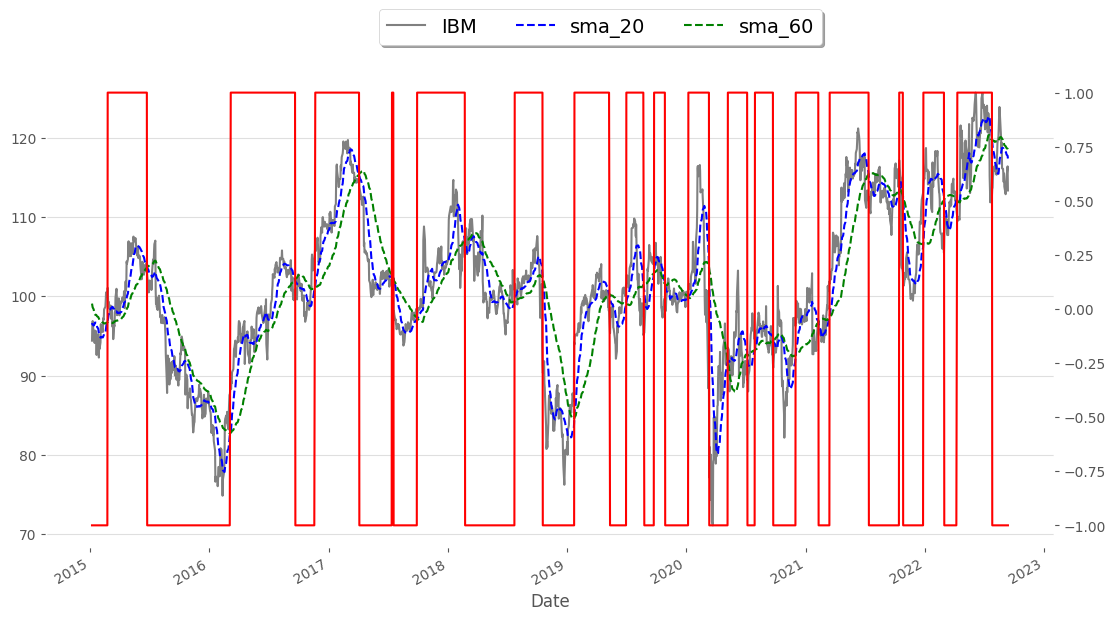

In [17]:
ax =\
(
    ibm
    [['IBM', 'sma_20', 'sma_60', 'positions']]
    .plot(
        secondary_y = "positions",
        style = ["grey", "b--", "g--", "r"],
        figsize = [13, 7]
    )
)

ax.xaxis.grid(False)

(
    ax
    .legend(
        loc="upper center",
        bbox_to_anchor = (0.55, 1.15),
        ncol=4,
        shadow=True
    )
)

### <font color = red> Question 3</font>. Based on your lines of codes that lead to answer 2 above, compare the returns to see if the strategy leads to a win over the passive benchmark investment.

<Axes: xlabel='Date'>

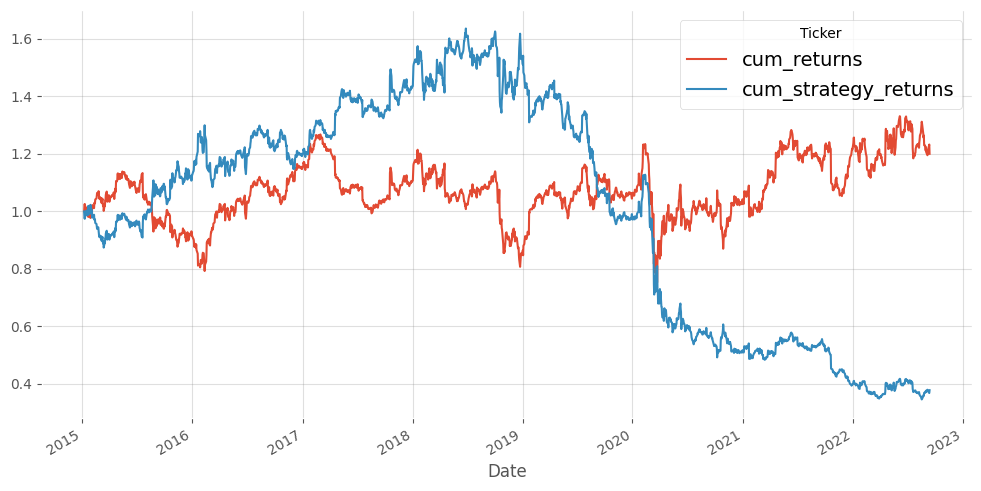

In [18]:
ibm[ibm.columns[-2:]].plot(
    figsize=[12,6]
)

### <font color = red> Question 4</font>. Based on your lines of codes that lead to answer 3 above, please calculate the maximum drawdown and the longest drawdown period.

In [19]:
def get_drawdowns(cum_returns):
    """
    Calculate the Maximum Drawdown (MDD) and the Longest Drawdown Duration (LDD)
    from a cumulative returns SERIES.

    Parameters:
      cum_returns : pd.SERIES of cumulative returns
    Returns:
      tuple (mdd, ldd)
    Usage: 
      get_drawdowns(df['cum_strategy_returns'])
    """
    def compute_longest_drawdown_period(dd, cum_returns):
      periods =\
      (
          np
          .diff(np.append(dd[dd == 0].index,
                          dd.index[-1: ]
                        )
              )
      )
      return periods.max() / np.timedelta64(1, "D")
    
    daily_drawdown = cum_returns / cum_returns.cummax() - 1
    mdd = daily_drawdown.min()
    ldd = compute_longest_drawdown_period(daily_drawdown, cum_returns) # days
    return mdd, ldd

get_drawdowns(ibm['cum_strategy_returns'])

(np.float64(-0.7884467299394011), np.float64(1539.0))

In [20]:
ibm['cum_strategy_returns']

Date
2015-01-07    1.000000
2015-01-08    0.978727
2015-01-09    0.974483
2015-01-12    0.991115
2015-01-13    0.988777
                ...   
2022-09-07    0.376970
2022-09-08    0.374740
2022-09-09    0.372652
2022-09-12    0.368459
2022-09-13    0.378333
Name: cum_strategy_returns, Length: 1935, dtype: float64

In [21]:
mdd, ldd = get_drawdowns(ibm['cum_strategy_returns'])

In [22]:
print(f'The maximum drawdown is about {mdd:.1%} percentage points.')
print(f'The longest drawdown period lasts for {ldd:.0f} days.')

The maximum drawdown is about -78.8% percentage points.
The longest drawdown period lasts for 1539 days.


### Please make sure to answer below.

    The maximum drawdown is about ___________ percentage points.
    The longest drawdown period lasts for ___________ days.

### <font color = red> Question 5</font>. Now let’s have a look at the stock price of Walmart (WMT). Please run a simple moving average crossover strategy.

### The two moving windows are 50 and 200 days.

### Now, please visualize your buy positions using red dots, and your sell positions using blue dots.

In [23]:
wmt =\
(
    df['Close'][['WMT']]
)

In [24]:
wmt =\
get_momentum_strategy(wmt, (50, 200)).dropna()

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_44493/2194077980.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['positions'] =\
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_44493/2194077980.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['trade'] = \
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_44493/2194077980.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = va

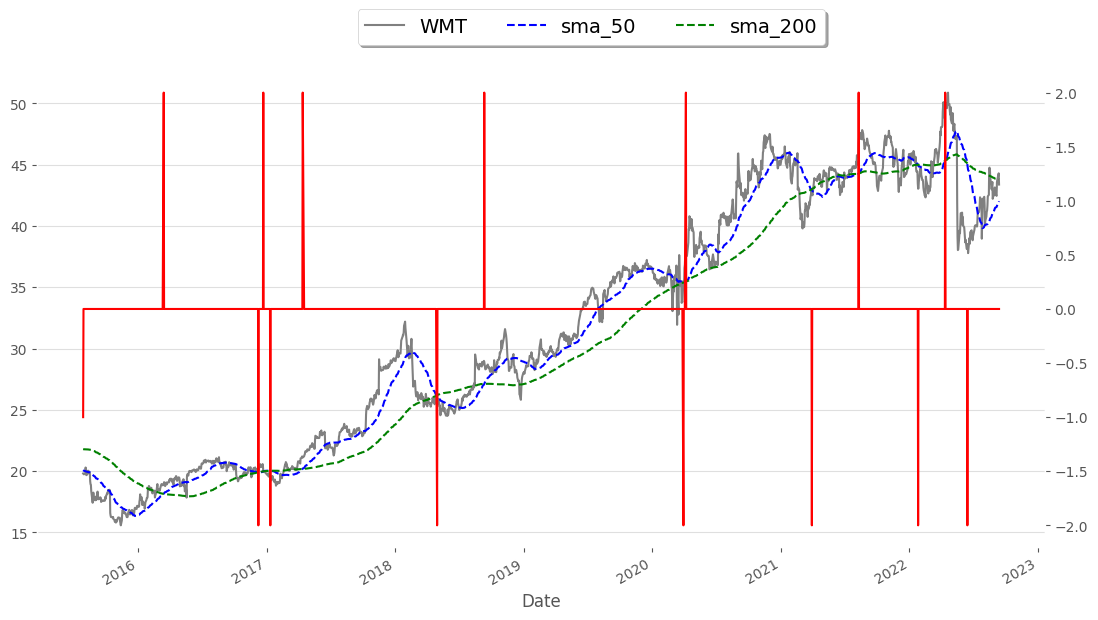

In [25]:
ax =\
(
    wmt
    [["WMT", "sma_50", "sma_200", "trade"]]
    .plot(secondary_y = "trade",
          style = ["grey", "b--", "g--", "r"],
          figsize = [13, 7]
         )
)

ax.xaxis.grid(False)

(
    ax
    .legend(loc = "upper center",
            bbox_to_anchor = (0.55, 1.15),
            ncol = 4,
            shadow = True
           )
)

In [26]:
wmt.reset_index()

Ticker,Date,WMT,sma_50,sma_200,positions,trade,passive_returns,strategy_returns,cum_returns,cum_strategy_returns
0,2015-07-29,19.805679,20.079336,21.794393,-1,-1.0,0.000000,0.000000,1.000000,1.000000
1,2015-07-30,19.786491,20.055919,21.788871,-1,0.0,-0.000969,0.000969,0.999031,1.000970
2,2015-07-31,19.737135,20.034421,21.782536,-1,0.0,-0.002498,0.002498,0.996539,1.003473
3,2015-08-03,19.791975,20.012869,21.780220,-1,0.0,0.002775,-0.002775,0.999308,1.000692
4,2015-08-04,19.811157,19.993071,21.779858,-1,0.0,0.000969,-0.000969,1.000277,0.999723
...,...,...,...,...,...,...,...,...,...,...
1790,2022-09-07,43.546246,41.627555,43.840473,-1,0.0,0.025367,-0.025367,2.198675,0.684071
1791,2022-09-08,43.767609,41.721171,43.834505,-1,0.0,0.005071,-0.005071,2.209851,0.680611
1792,2022-09-09,43.899139,41.820291,43.825422,-1,0.0,0.003001,-0.003001,2.216492,0.678572
1793,2022-09-12,44.293732,41.929476,43.816685,-1,0.0,0.008948,-0.008948,2.236416,0.672527


In [27]:
# TODO get_plot lets-plot; basic 
from lets_plot import *
LetsPlot.setup_html()

wmt_melt = wmt.reset_index()
# wmt_melt = wmt_melt.rename(columns={'index':'Date'}). # optional depending if index is called 'Date'

p =\
(
    ggplot(wmt_melt, aes(x='Date')) +
    geom_line(aes(y='WMT'), color='grey', size=0.7) +
    geom_line(aes(y='sma_50'), color='orange', size=0.7,linetype=2) +   # amend sma as required
    geom_line(aes(y='sma_200'), color='blue', size=0.7,linetype=2) +
    geom_point(aes(y='sma_50'), data=wmt_melt[wmt_melt['trade']>0.0], color='red', size=3) +       # amend trade as required
    geom_point(aes(y='sma_50'), data=wmt_melt[wmt_melt['trade']<-0.0], color='blue', size=3) +
    ggtitle("Price Action with Signals") +
    ylab("Stock Price") +
    xlab("Date") +
    ggsize(1200, 500) 
)


p

In [28]:
wmt['trade'][wmt['trade'] != 0].count()

np.int64(15)

### Then, please come up with an answer for the question below.

    Based on simple moving average crossover strategy, there were _______ trading opportunities found.

### <font color = red> Question 6</font> Please draw the strategy returns as shown below.

### <mark> What is shown below is a sample to illustrate the type of visualization you should display; the results you obtain may not necessarily be the same.</mark>

<Axes: xlabel='Date'>

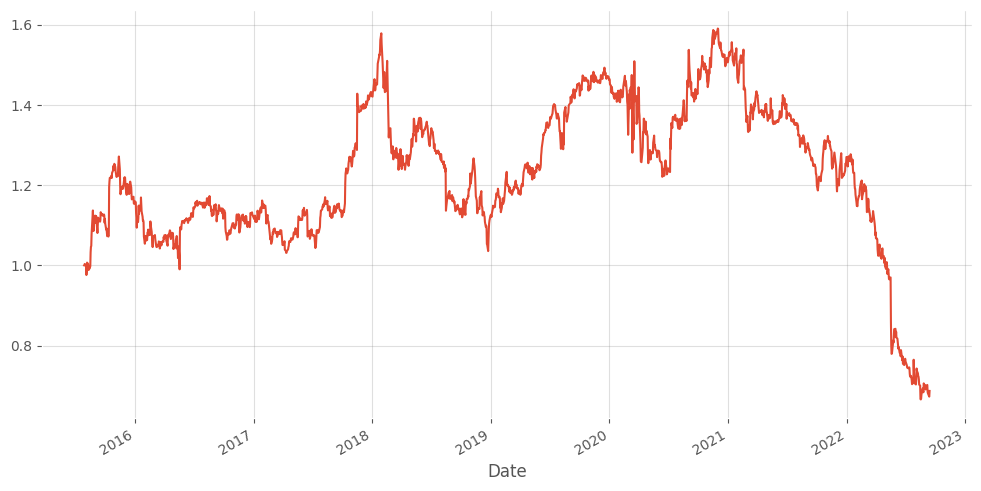

In [29]:
wmt['cum_strategy_returns'].plot(
    figsize=[12,6]
)

### <font color = red> Question 7</font>. Please calculate the Sharpe Ratio of the strategies for `IBM` and `WMT`, respectively.

    Simple moving strategy for IBM leads to a Sharpe ratio of _________ . 

    Simple moving strategy for WMT leads to a Sharpe ratio of _________ . 

In [31]:
compute_sharpe_ratio(ibm['strategy_returns'])

np.float64(-0.5105117214145133)

In [30]:
compute_sharpe_ratio(wmt['strategy_returns'])

np.float64(-0.23496884631227968)

### <font color = red> Question 8</font>. Please calculate the Compound Annual Growth Rate (CAGR) of the strategies for `IBM` and `WMT`, respectively.

    Simple moving strategy for IBM leads to a CAGR of _________ .

    Simple moving strategy for WMT leads to a CAGR of _________ .


In [33]:
compute_CAGR(ibm['cum_strategy_returns'])

np.float64(-0.11876747509149566)

In [35]:
compute_CAGR(wmt['cum_strategy_returns'])

np.float64(-0.05133881414662034)

### <font color="green">"Thank you for putting your efforts into the exercise problem sets 💯"</font>